# Data preprocessing #1

For preprocessing in the first round we need to: 

1. Understand the data
2. Split the data into a development and out-of-sample validation dataset (as well as potentially out of time dataset)
3. Clean data and safe it as function for the validation data
4. Remove outliers and other noise from the development dataset

## Importing relevant packages / libraries

In [1]:
import pandas as pd
import numpy as np
import importlib

## Loading in the complete dataset

In [2]:
df = pd.read_csv(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\data\customers.csv", index_col=0)

## 1. Understand the data

In this section we attempt to get an understand of the dataset we need to work with.

In [3]:
df.shape

(8000, 20)

The dataset contain 20 columns with 8000 observations, and it is apperent from the data_pipelines.ipynb that there is no missing in any column.

In [4]:
uniques = {}

for col in df.columns:
    uniques[col] = [len(pd.unique(df[col]))]

unique_df = pd.DataFrame(uniques).T
unique_df.columns = ["Count of unique values"]
display(unique_df)

,Count of unique values
customer_id,8000
country,20
age,57
gender,3
membership_tier,4
registration_date,1862
total_orders,79
total_spend_usd,7864
avg_order_value_usd,6365
days_since_last_purchase,336


It can be noted that there are only unique customer IDs as there is 8000 unique IDs and 8000 rows in the dataset. 

The churned column will be threated as the target variable and customer ID can be seen as an observation identifier.

It should also be noted there is no time column hence no out-of-time validation dataset is possible. 

In [5]:
print("Churn rate: " + str(round(sum(df["churned"])*100/len(df["churned"]), 2)) + "%")

Churn rate: 8.94%


It is clear that the churn rate is rather low, and the dataset is imbalanced therefore we have to be careful when splitting the dataset into an OOS validation set and development set.

## Splitting into development data and OOS

To split into a development dataset and OOS dataset we use the train_test_split from sklearn

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
train, test = train_test_split(df, test_size=500/8000, random_state=42)

In [8]:
print("Churn rate of train: " + str(round(sum(train["churned"])*100/len(train["churned"]), 2)) + "%")
print("Churn rate of test: " + str(round(sum(test["churned"])*100/len(test["churned"]), 2)) + "%")

Churn rate of train: 8.91%
Churn rate of test: 9.4%


After confirming the churn rate of each set is reasonable the test and development set are saved.

In [9]:
test.to_csv(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\data\oos_data.csv", sep = ",", decimal=".")
train.to_csv(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\data\development_data.csv", sep = ",", decimal=".")

## Analysis of outlier

First the columns are split into categorical and continues variables. For continues variables the variable have to be a float or integer and secondly there must be more that 20 unique values

In [10]:
train.drop(columns=["customer_id"], inplace=True)

In [11]:
cont_col = [col for col in train.columns if (len(pd.unique(train[col])) > 20) 
            & ((type(train[col][0]) == np.float64) | (type(train[col][0]) == int) | (type(train[col][0]) == np.int64))]

In [12]:
cont_col

['age',
 'total_orders',
 'total_spend_usd',
 'avg_order_value_usd',
 'days_since_last_purchase',
 'reviews_given',
 'avg_review_score',
 'wishlist_items']

In [13]:
cat_col = list(set(train.columns) - set(cont_col))

In [14]:
cat_col

['preferred_device',
 'membership_tier',
 'newsletter_subscribed',
 'acquisition_channel',
 'preferred_category',
 'returns_made',
 'preferred_payment_method',
 'country',
 'registration_date',
 'churned',
 'gender']

In [15]:
import matplotlib.pyplot as plt

In [16]:
len(cont_col)

8

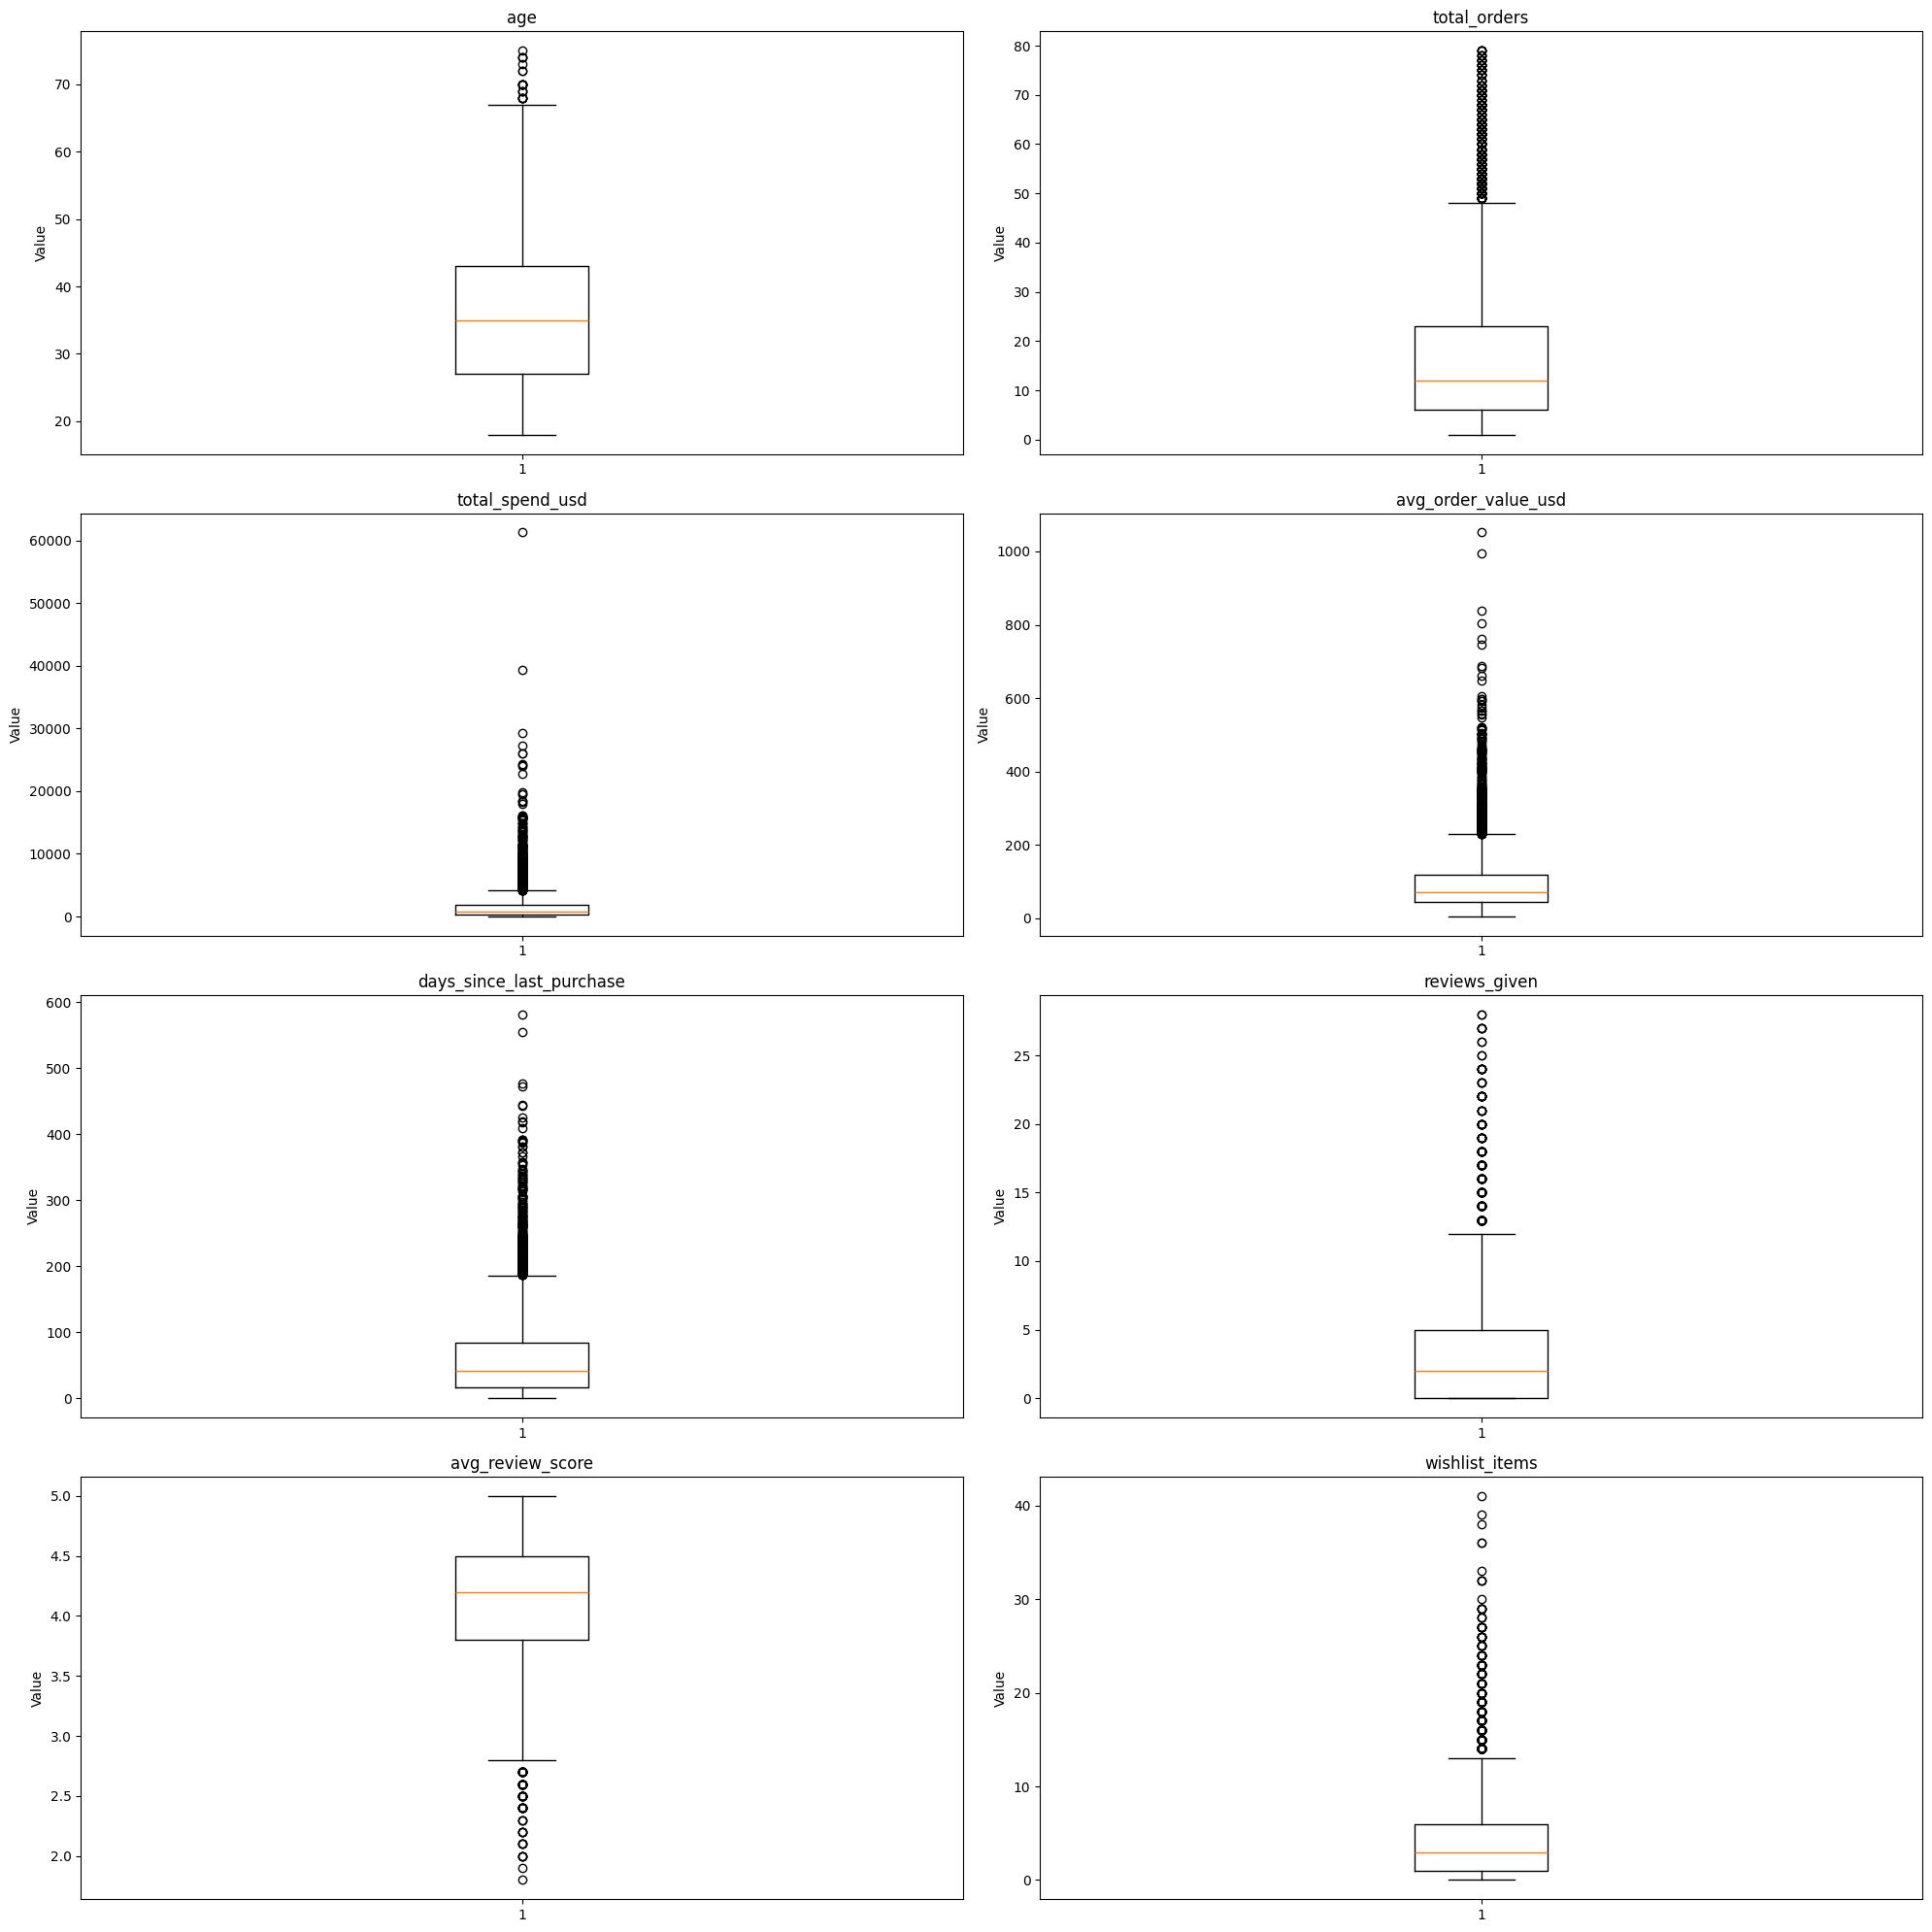

In [17]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(cont_col):
    axes[i].boxplot(train[var])
    axes[i].set_title(var)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

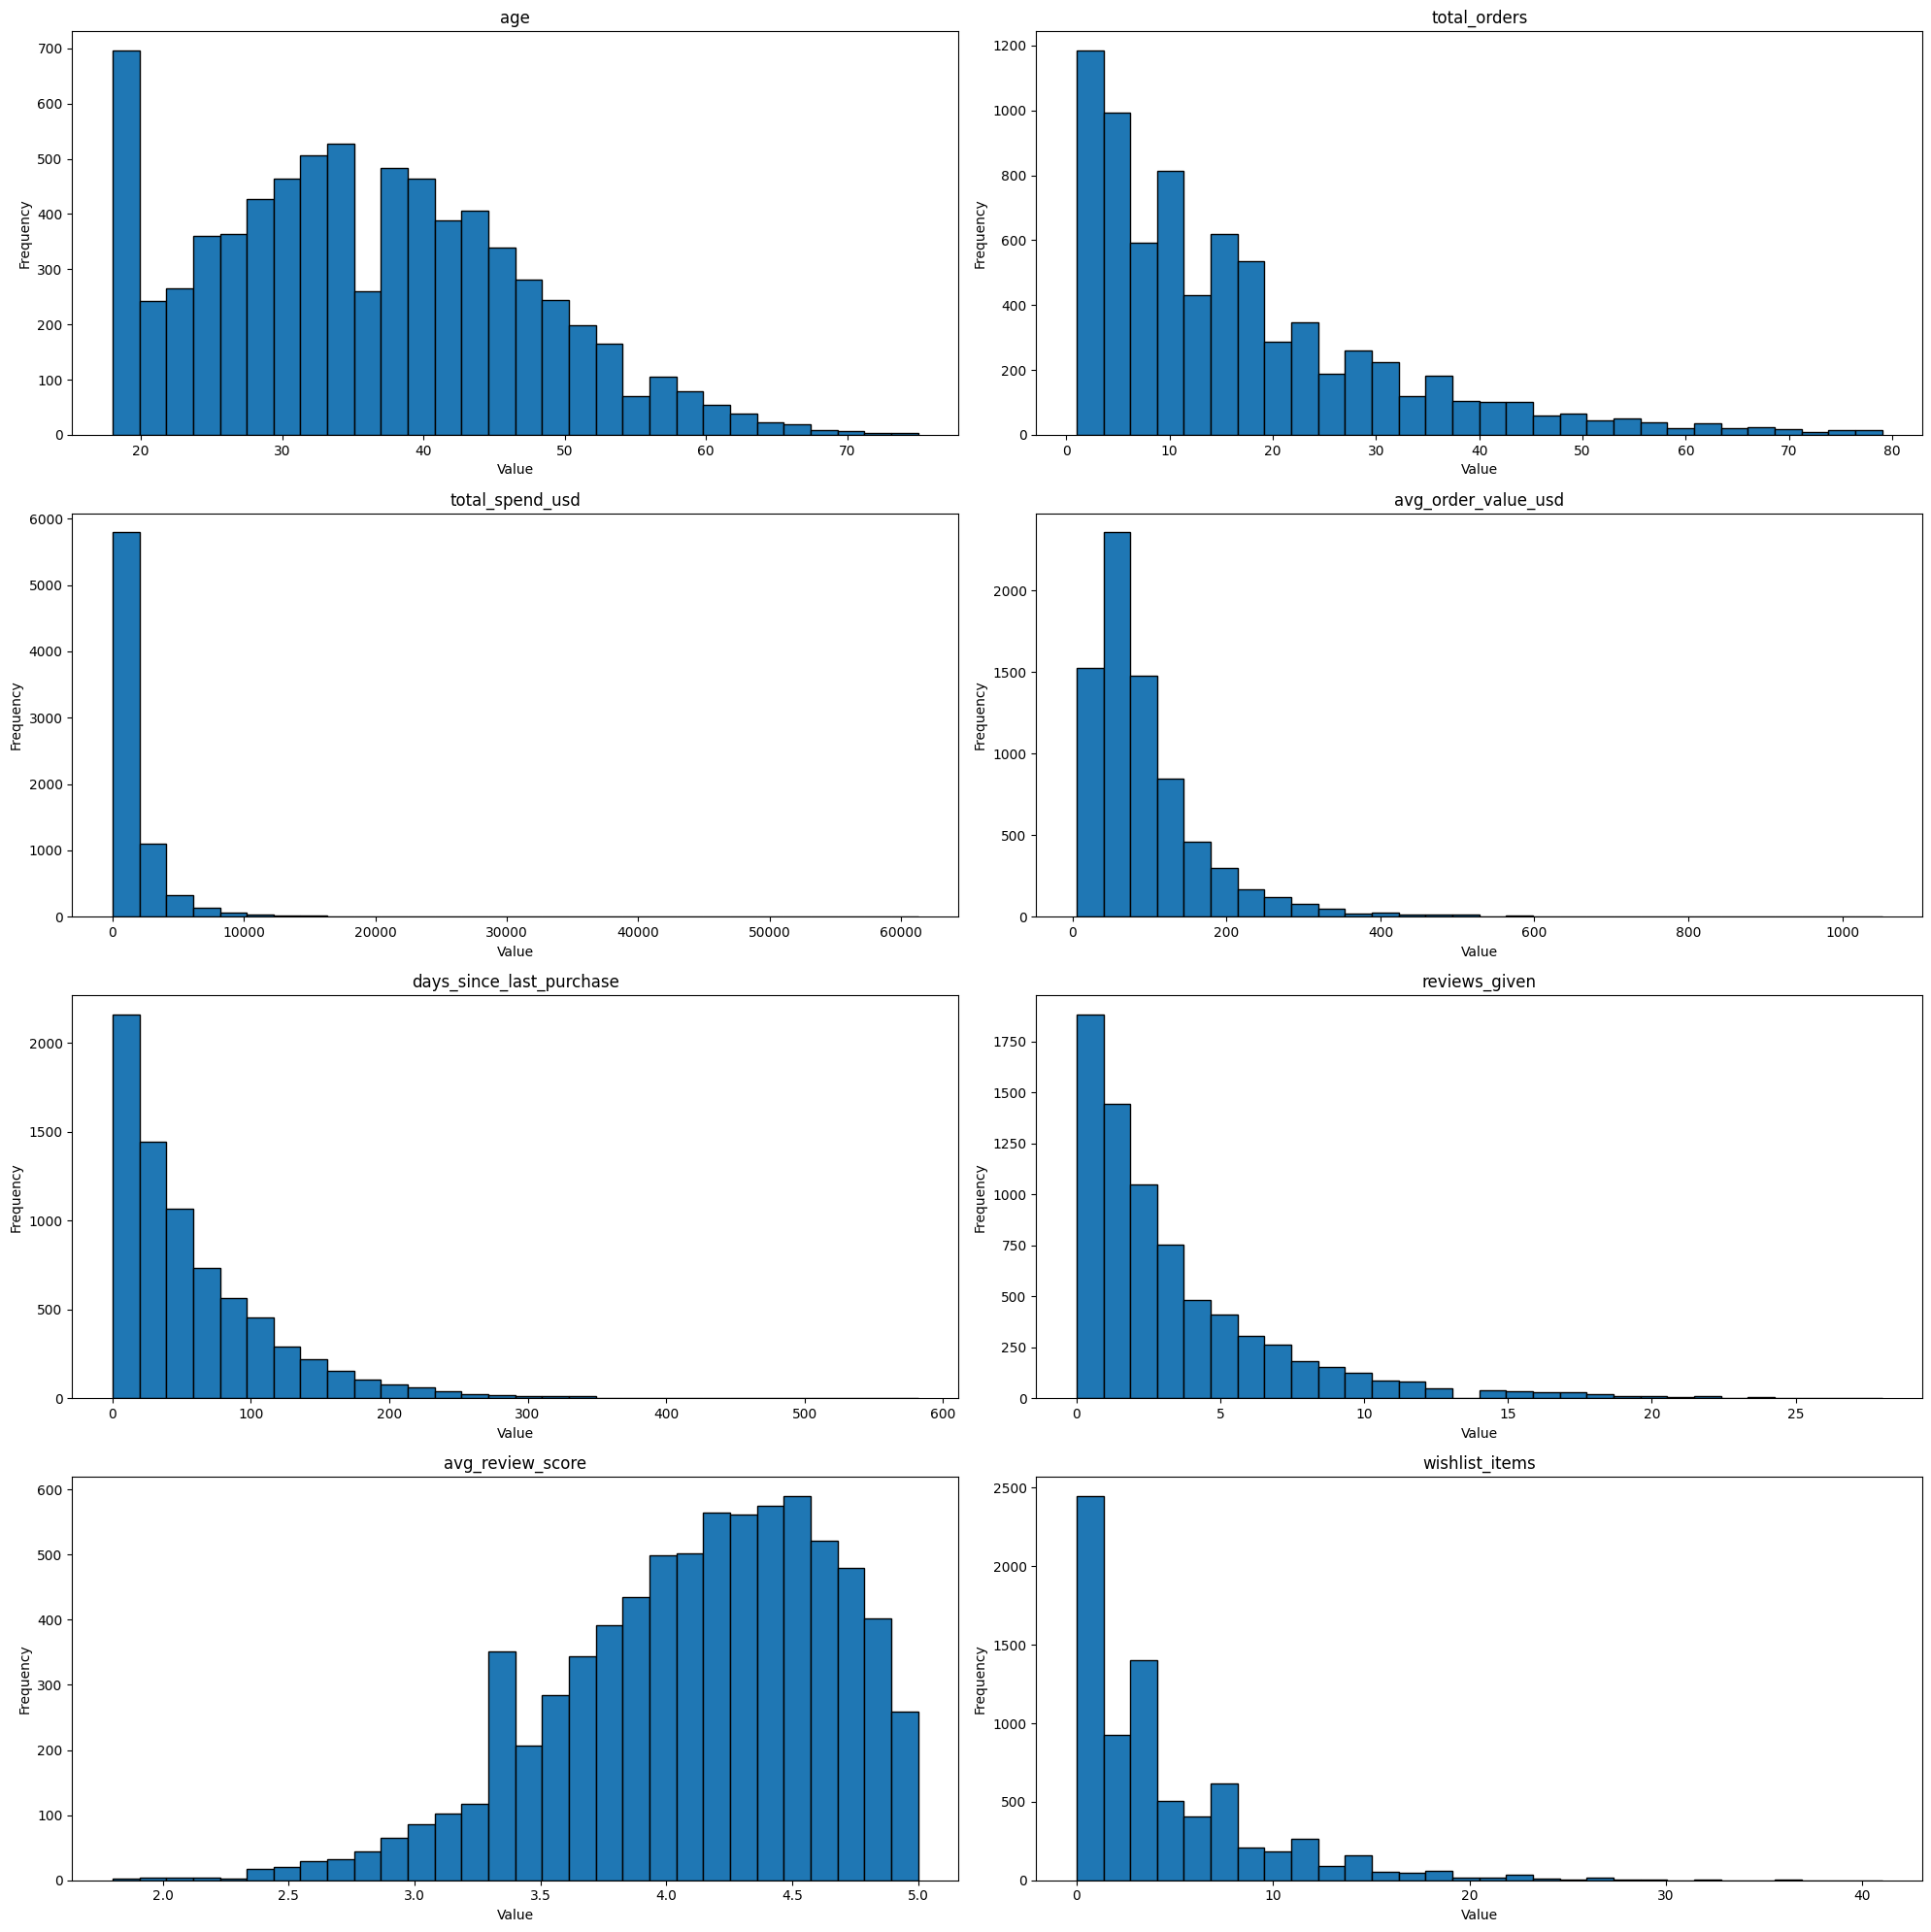

In [18]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(cont_col):
    axes[i].hist(train[var], bins=30, edgecolor='black')
    axes[i].set_title(var)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Since the distributions of all continious variables except avg_review_score and age seems to have an approximately exponential decreasing distribution they are capped at the 975% percentile. For age the distributions look more bell curved yet are missing tails in each end here the IQR-method is applied.

To keep the outlier handling simple it is saved in the modul outlier_handler.py

In [19]:
import python_modules.src.outlier_handler
importlib.reload(python_modules.src.outlier_handler)

from python_modules.src.outlier_handler import cont_outliers

In [20]:
train = cont_outliers(train)

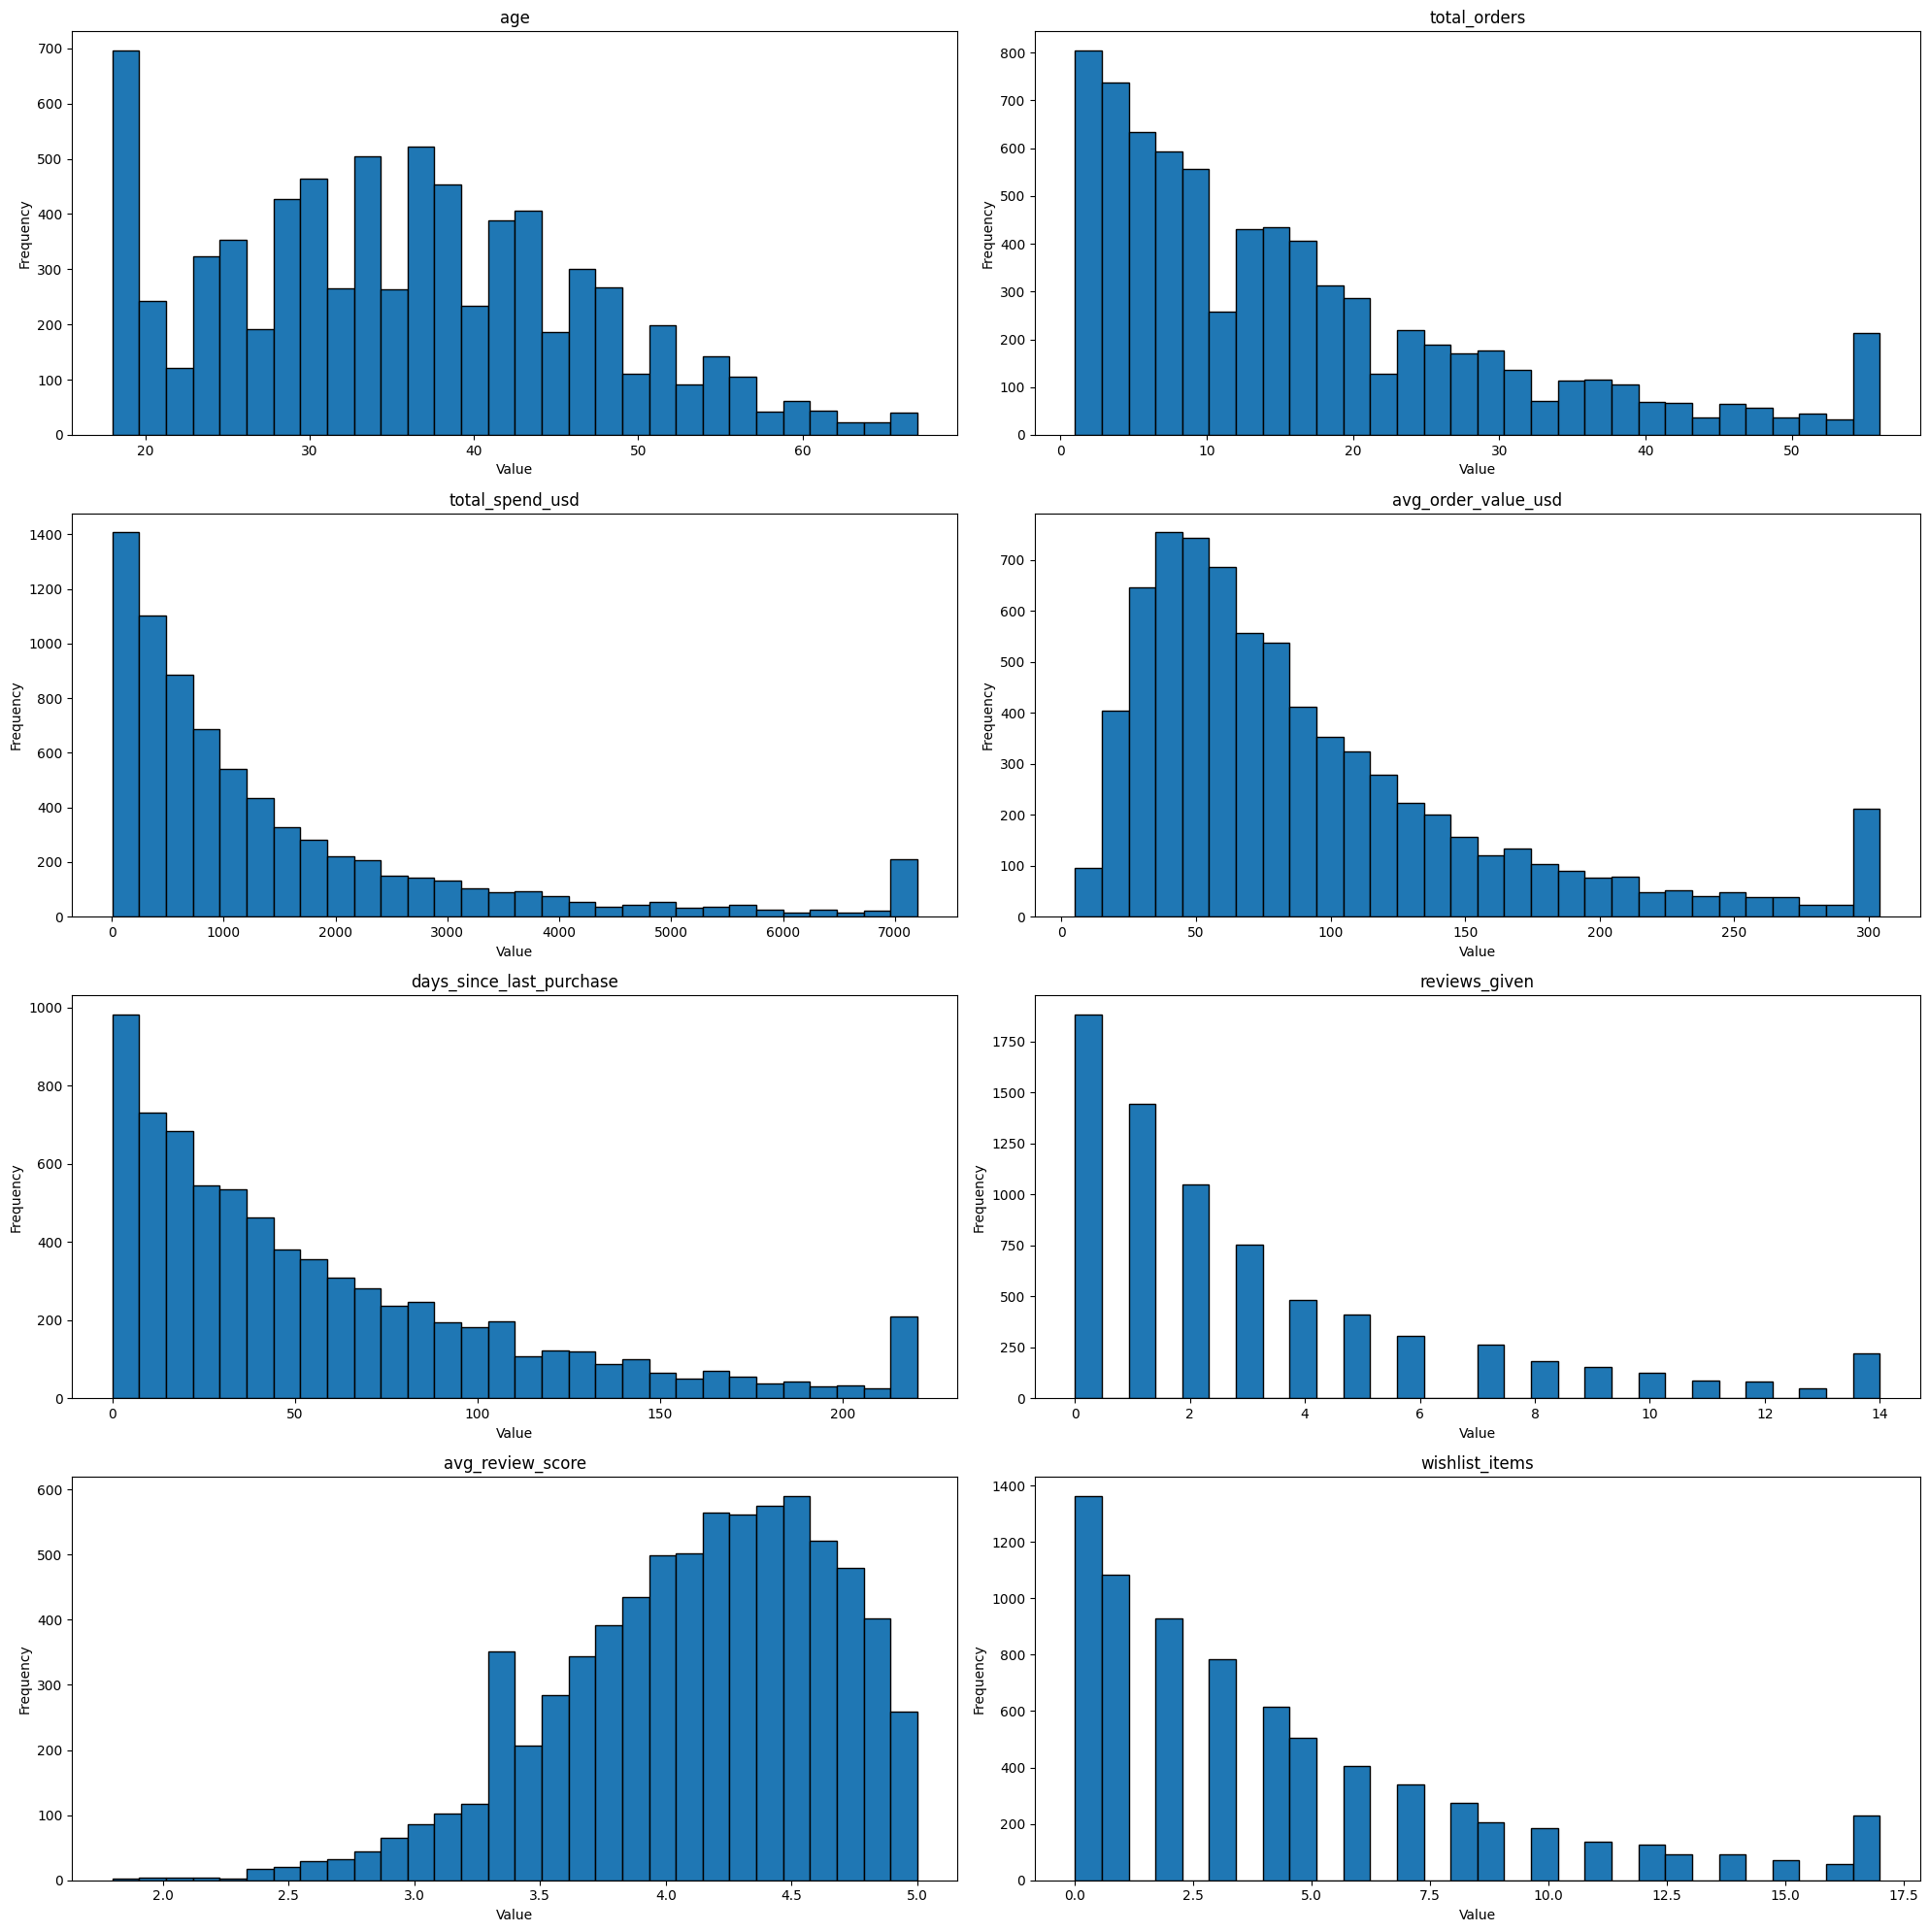

In [21]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(cont_col):
    axes[i].hist(train[var], bins=30, edgecolor='black')
    axes[i].set_title(var)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

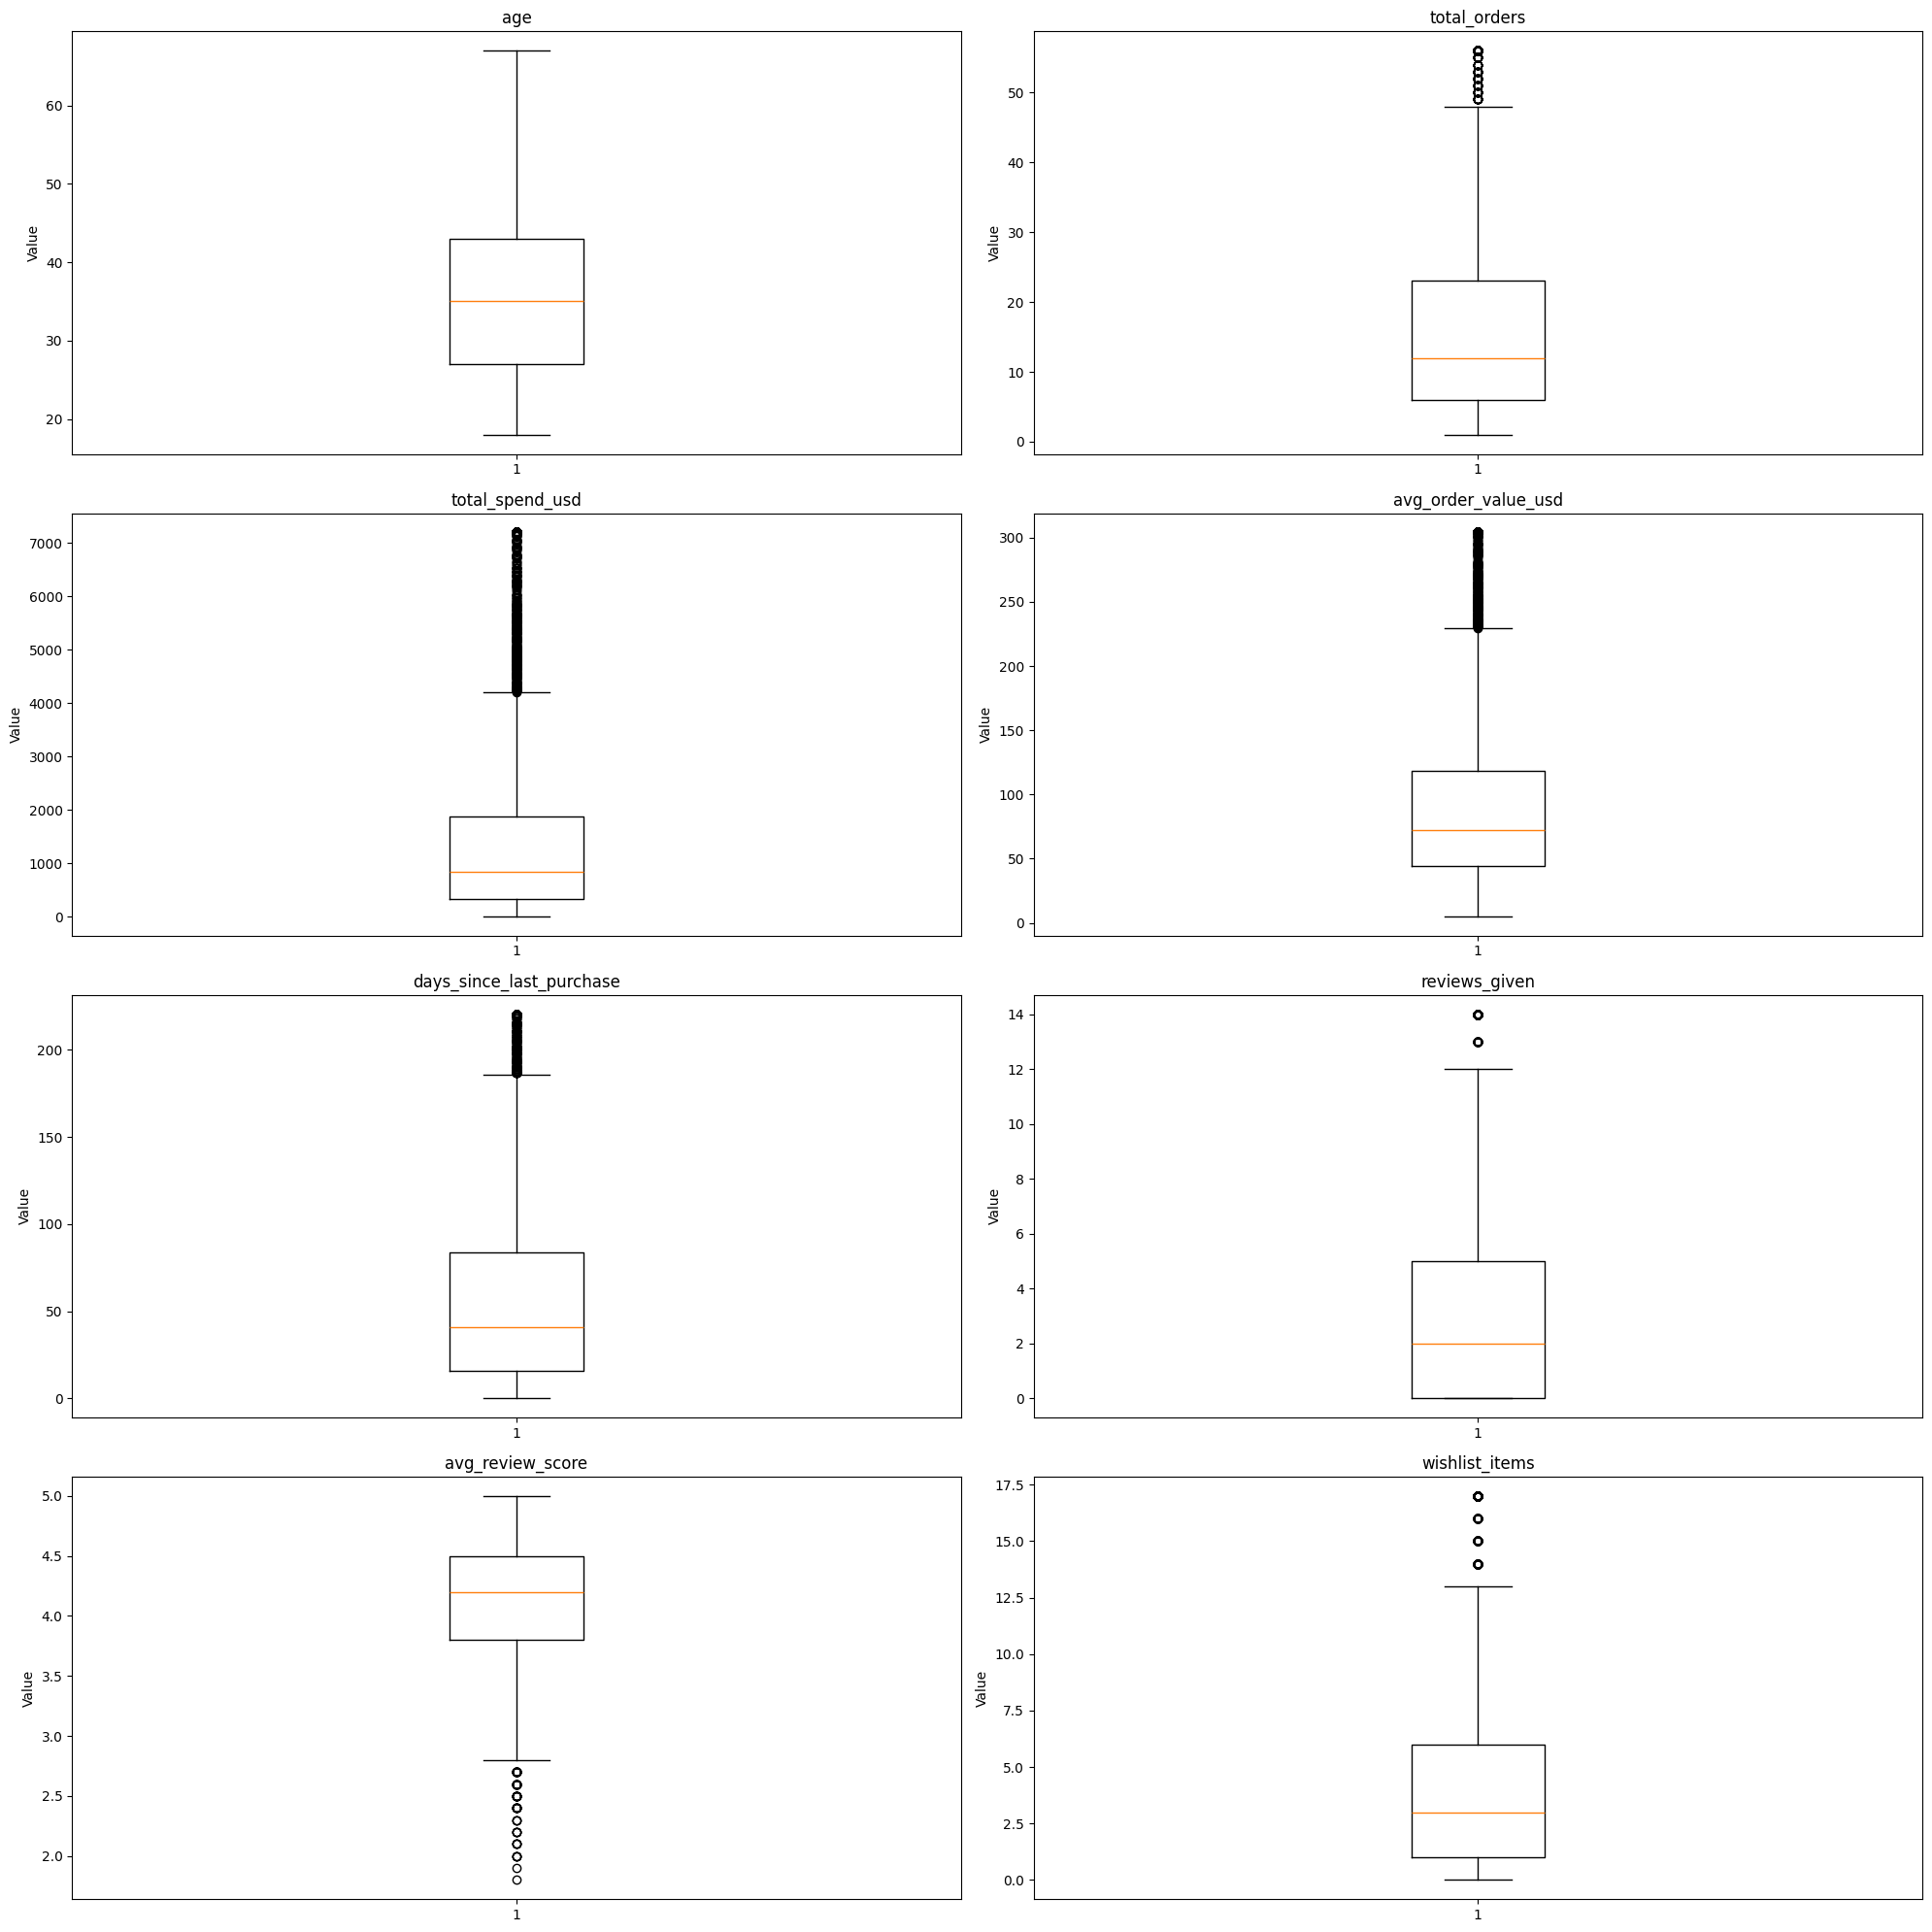

In [22]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(cont_col):
    axes[i].boxplot(train[var])
    axes[i].set_title(var)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

The boxplots and distributions looks alot more reasonable and managable.

Now for handling categorical variable.

In [23]:
len(cat_col)

11

In [24]:
help(plt.xticks)

Help on function xticks in module matplotlib.pyplot:

xticks(ticks: 'ArrayLike | None' = None, labels: 'Sequence[str] | None' = None, *, minor: 'bool' = False, **kwargs) -> 'tuple[list[Tick] | np.ndarray, list[Text]]'
    Get or set the current tick locations and labels of the x-axis.
    
    Pass no arguments to return the current values without modifying them.
    
    Parameters
    ----------
    ticks : array-like, optional
        The list of xtick locations.  Passing an empty list removes all xticks.
    labels : array-like, optional
        The labels to place at the given *ticks* locations.  This argument can
        only be passed if *ticks* is passed as well.
    minor : bool, default: False
        If ``False``, get/set the major ticks/labels; if ``True``, the minor
        ticks/labels.
    **kwargs
        `.Text` properties can be used to control the appearance of the labels.
    
        .. warning::
    
            This only sets the properties of the current ticks, 

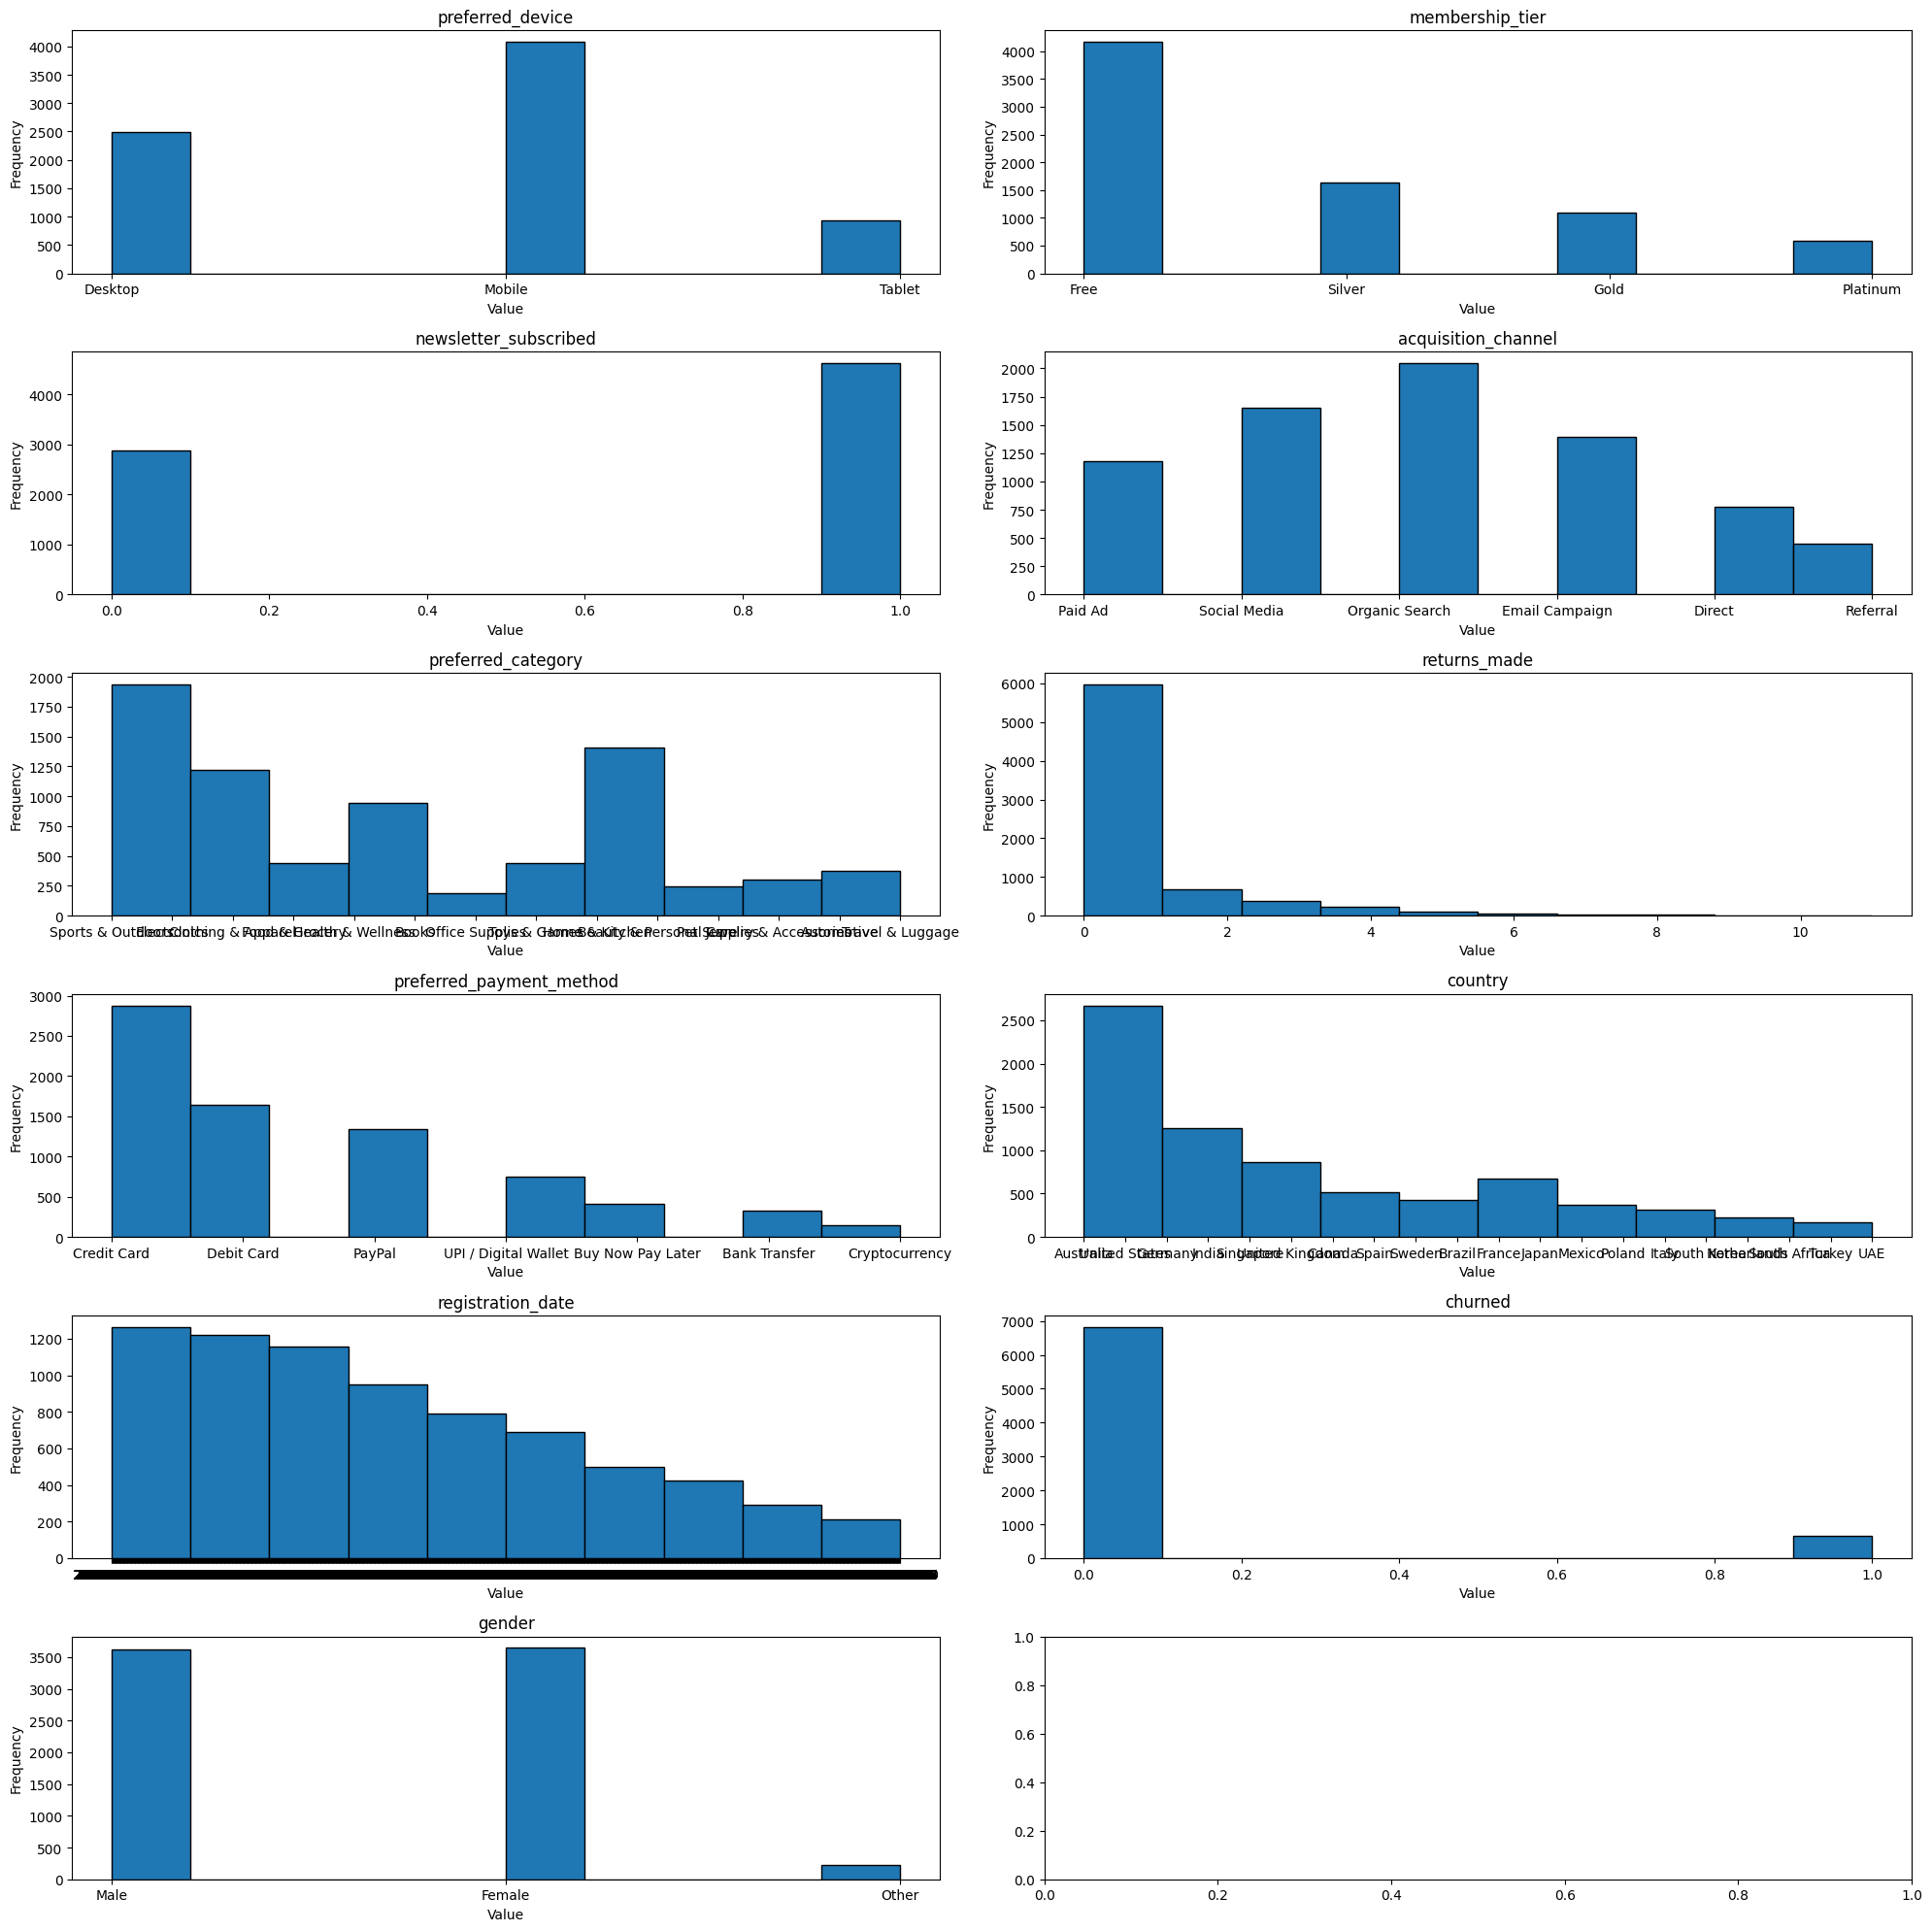

In [25]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(cat_col):
    axes[i].hist(train[var], edgecolor='black')
    axes[i].set_title(var)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

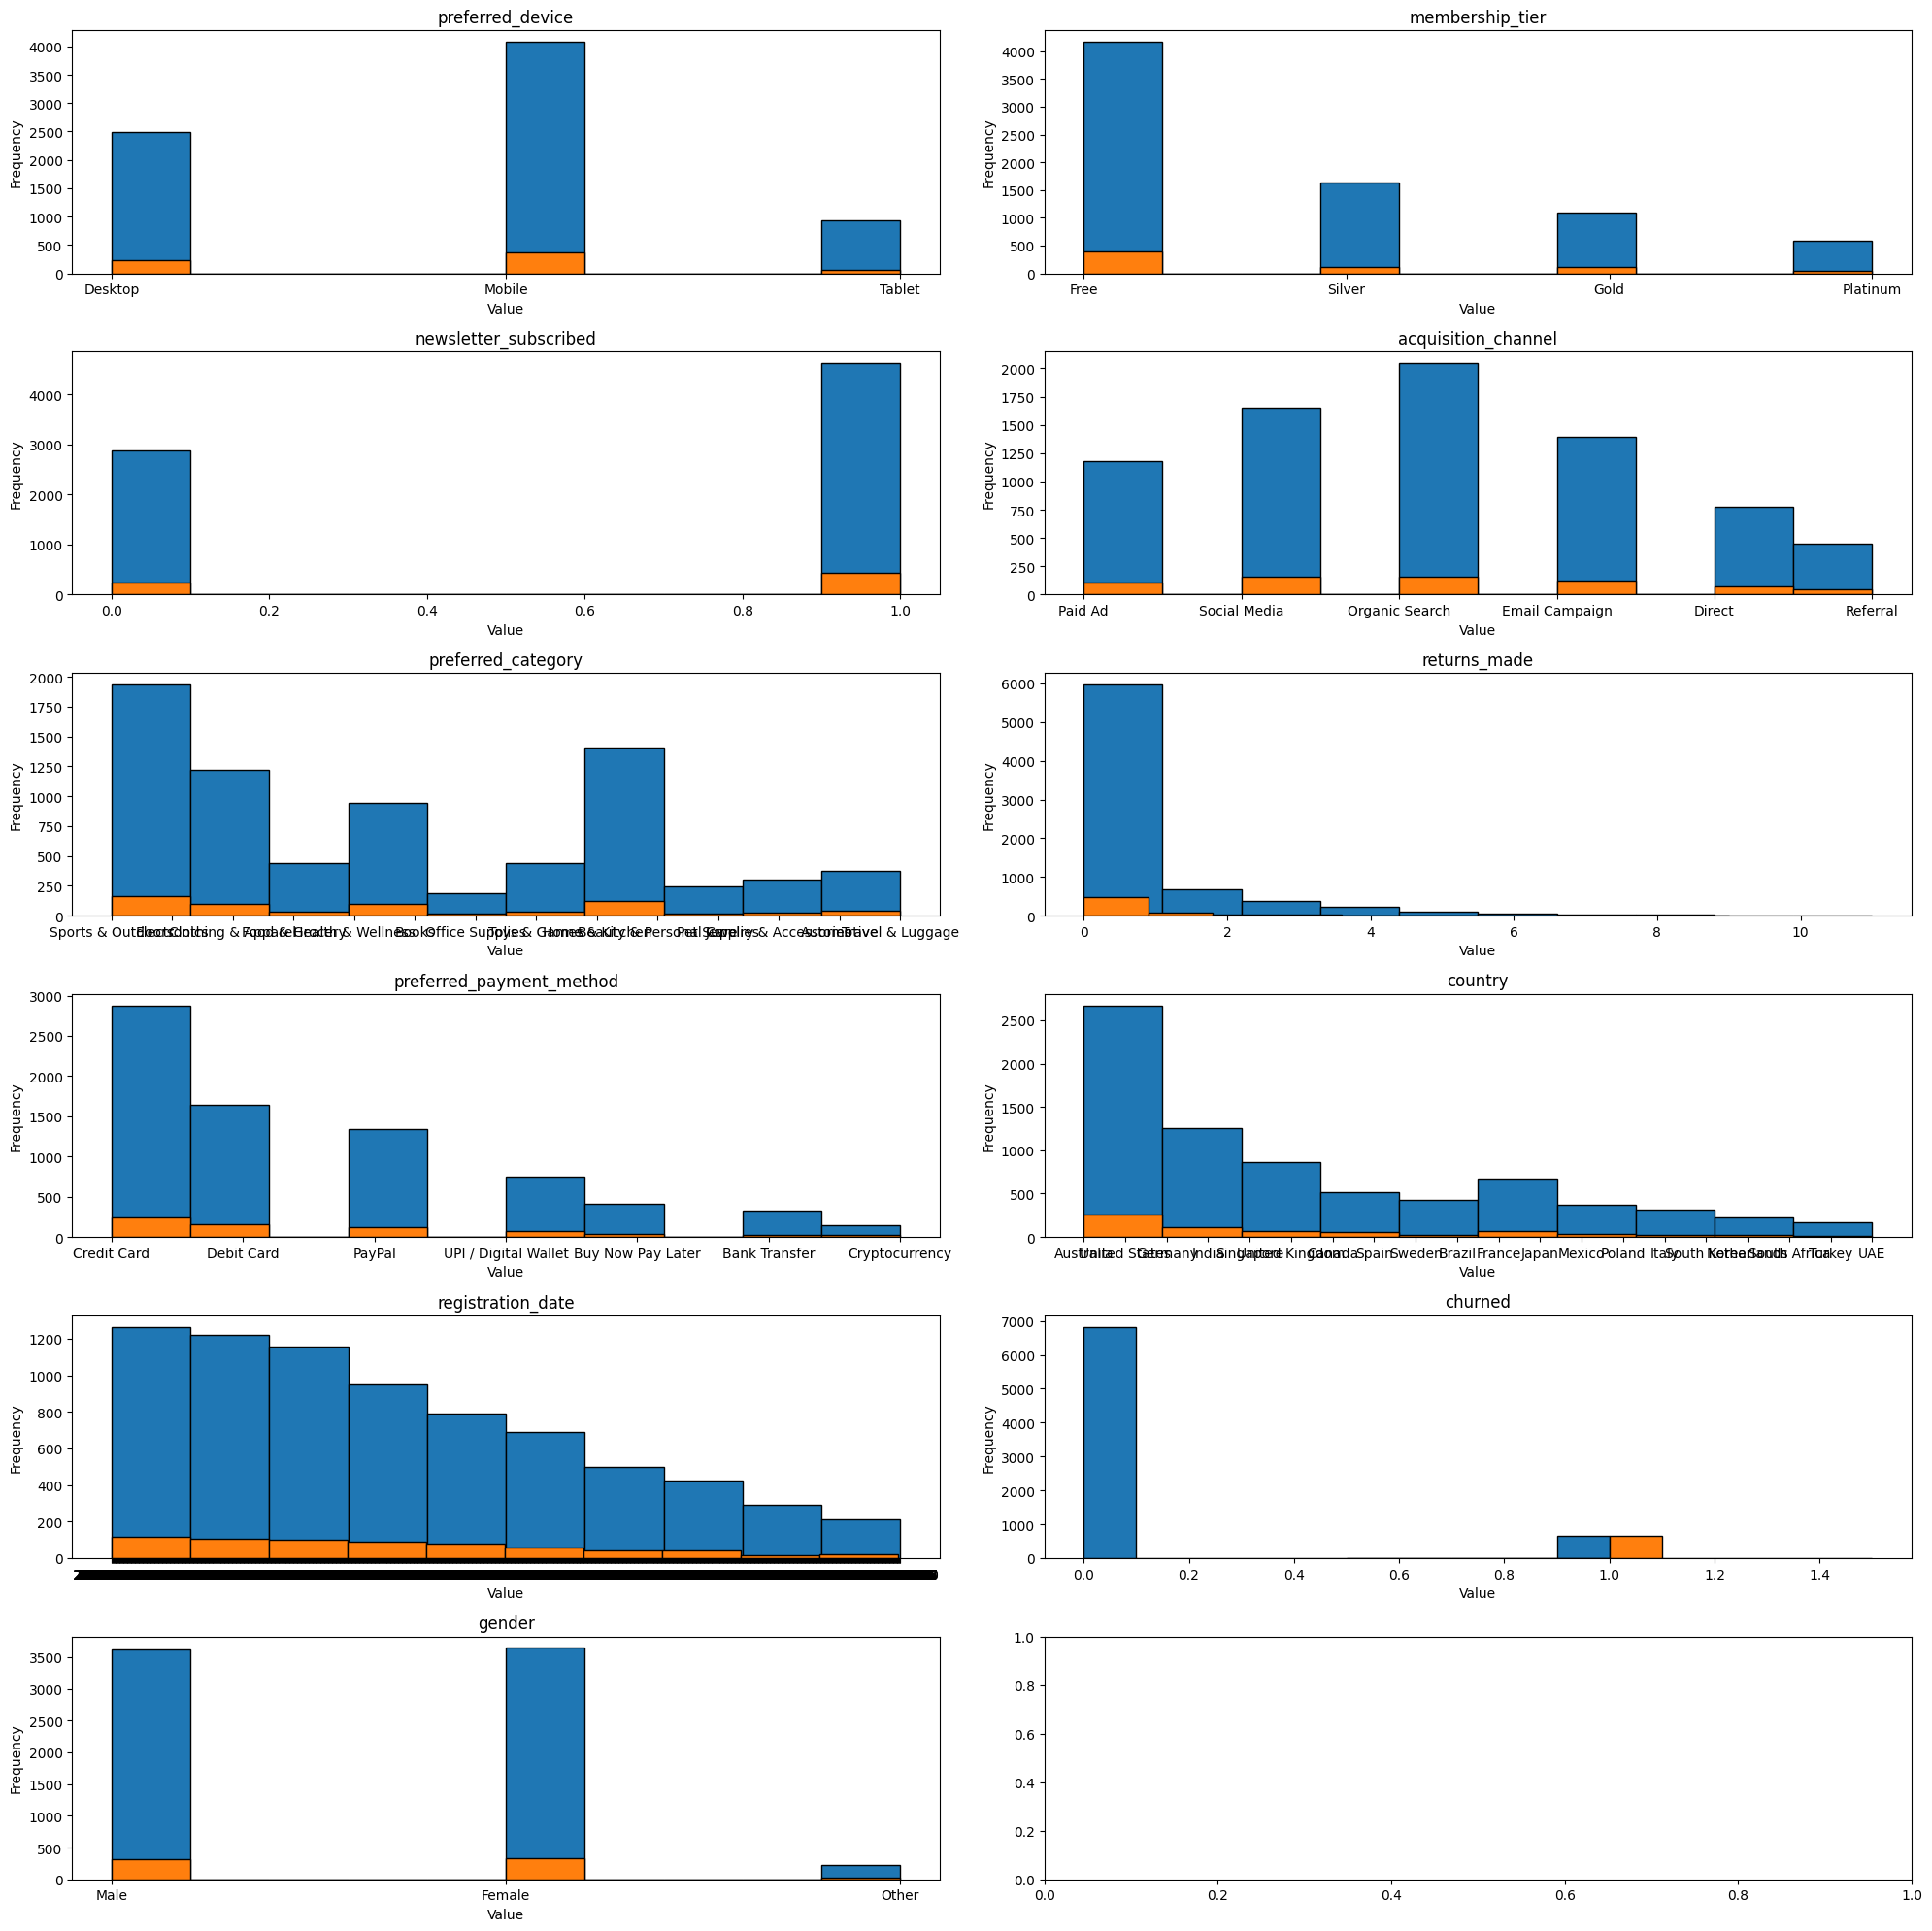

In [30]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(cat_col):
    axes[i].hist(train[var], edgecolor='black')
    axes[i].hist(train[train["churned"] == 1][var], edgecolor='black')
    axes[i].set_title(var)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

It is not easy to judge if there is any significant outliers by the graph alone 

In [34]:
cat_col.remove("churned")

In [35]:
import pickle

In [36]:
col_type = {
    "continious": cont_col,
    "categorical": cat_col
}

In [37]:
with open(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\pickle\cont_cat.pkl", 'wb') as f:
    pickle.dump(col_type, f)